[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Daniel-534/gw-lvk-python-course/blob/main/Course/Lesson_02_First_Steps_with_GWOSC_and_Strain_Data.ipynb)

# Lesson 2 — First Steps with GWOSC and Strain Data

**LIGO–Virgo–KAGRA Python Course**

---

> *"Open science is not just about making data available — it is about making discovery reproducible, shareable, and inclusive."*  
> — Gravitational-Wave Open Science Center

---

## Table of Contents

1. [Introduction](#1-introduction)
2. [Environment Setup and Installation](#2-environment-setup-and-installation)  
   2.1 [Why These Libraries?](#21-why-these-libraries)  
   2.2 [Installing with pip and conda](#22-installing-with-pip-and-conda)  
   2.3 [Verifying the Installation](#23-verifying-the-installation)  
   2.4 [Working in the Cloud (Google Colab / Binder)](#24-working-in-the-cloud-google-colab--binder)  
3. [Understanding GPS Time](#3-understanding-gps-time)  
   3.1 [What is GPS Time?](#31-what-is-gps-time)  
   3.2 [Leap Seconds and TAI](#32-leap-seconds-and-tai)  
   3.3 [Converting GPS Time in Python](#33-converting-gps-time-in-python)  
   3.4 [The GPS Epoch of GW150914](#34-the-gps-epoch-of-gw150914)  
4. [The GWOSC Python Package (`gwosc`)](#4-the-gwosc-python-package-gwosc)  
   4.1 [Package Overview](#41-package-overview)  
   4.2 [Querying the Event Catalogue](#42-querying-the-event-catalogue)  
   4.3 [Retrieving Event Parameters](#43-retrieving-event-parameters)  
   4.4 [Listing Available Data Sets](#44-listing-available-data-sets)  
   4.5 [Finding Data URLs](#45-finding-data-urls)  
5. [Downloading Strain Data](#5-downloading-strain-data)  
   5.1 [Strain: A Quick Recap](#51-strain-a-quick-recap)  
   5.2 [Downloading via `gwpy`](#52-downloading-via-gwpy)  
   5.3 [Downloading via `gwosc` and Direct URLs](#53-downloading-via-gwosc-and-direct-urls)  
   5.4 [Understanding the File Name Convention](#54-understanding-the-file-name-convention)  
6. [Reading HDF5 Files](#6-reading-hdf5-files)  
   6.1 [The HDF5 Format](#61-the-hdf5-format)  
   6.2 [Exploring HDF5 Structure with `h5py`](#62-exploring-hdf5-structure-with-h5py)  
   6.3 [Extracting Strain, GPS Start, and Sample Rate](#63-extracting-strain-gps-start-and-sample-rate)  
   6.4 [Loading with `gwpy.timeseries.TimeSeries`](#64-loading-with-gwpytimeseriesTimeSeries)  
7. [Reading GWF Files](#7-reading-gwf-files)  
   7.1 [The Frame Format (.gwf)](#71-the-frame-format-gwf)  
   7.2 [Reading .gwf Files with `gwpy`](#72-reading-gwf-files-with-gwpy)  
   7.3 [Choosing the Right Channel Name](#73-choosing-the-right-channel-name)  
8. [Visualising and Understanding Strain Data](#8-visualising-and-understanding-strain-data)  
   8.1 [Time-Domain Plot](#81-time-domain-plot)  
   8.2 [Power Spectral Density (PSD)](#82-power-spectral-density-psd)  
   8.3 [The Amplitude Spectral Density (ASD)](#83-the-amplitude-spectral-density-asd)  
   8.4 [Q-Transform (Time–Frequency Representation)](#84-q-transform-timefrequency-representation)  
9. [Data Quality and Segments](#9-data-quality-and-segments)  
   9.1 [Data Quality Flags](#91-data-quality-flags)  
   9.2 [Querying Segments with `gwosc`](#92-querying-segments-with-gwosc)  
   9.3 [Science Mode and Analysis Segments](#93-science-mode-and-analysis-segments)  
10. [Working with PyCBC](#10-working-with-pycbc)  
    10.1 [PyCBC TimeSeries](#101-pycbc-timeseries)  
    10.2 [Fetching Open Data with PyCBC](#102-fetching-open-data-with-pycbc)  
11. [Student Exercises](#11-student-exercises)
12. [References](#12-references)

---
## 1. Introduction

In Lesson 1 we built the physical and astrophysical foundation: we understand what gravitational waves are, how interferometers detect them, and what the global detector network looks like. Now it is time to **get our hands on real data**.

The **Gravitational-Wave Open Science Center (GWOSC)** makes all strain data from LIGO, Virgo, and KAGRA publicly available. As of 2024, the cumulative open data set contains:

- **O1**: ~130 days of coincident LIGO data (2015–2016)
- **O2**: ~270 days of multi-detector data (2016–2017)
- **O3**: ~330 days of three-detector data including Virgo (2019–2020)
- **O4**: ongoing, data released in bulk at run end

This lesson is a **practical hands-on guide**. By the end you will be able to:

1. Install and import the three core gravitational-wave Python libraries.
2. Navigate the GWOSC event catalogue programmatically.
3. Download and read strain files in both HDF5 and GWF formats.
4. Work fluently with GPS timestamps.
5. Produce standard diagnostic plots (time series, ASD, Q-transform).
6. Query data-quality segments.

> **Tip:** Every code cell in this notebook is self-contained and runnable. We recommend running them **in order** the first time.

---
## 2. Environment Setup and Installation

### 2.1 Why These Libraries?

Three Python packages form the backbone of gravitational-wave data analysis:

| Package | Role | Key classes / functions |
|---------|------|-------------------------|
| [`gwosc`](https://gwosc.readthedocs.io) | Catalogue queries, URL lookup, segment queries | `datasets`, `locate`, `timeline` |
| [`gwpy`](https://gwpy.github.io) | Time series, FFTs, Q-transforms, I/O, plotting | `TimeSeries`, `FrequencySeries`, `Spectrogram` |
| [`pycbc`](https://pycbc.org) | Matched filtering, waveform generation, PSD estimation | `TimeSeries`, `FrequencySeries`, `filter`, `waveform` |

They are complementary rather than redundant. `gwosc` is a lightweight catalogue API; `gwpy` emphasises interactive exploration; `pycbc` is tuned for rigorous signal-processing pipelines.

**Other important dependencies** installed automatically:
- `numpy`, `scipy` — numerical foundations
- `matplotlib` — plotting
- `astropy` — time, units, coordinates
- `h5py` — HDF5 file I/O
- `LDAStools.frameCPP` or `framel` — GWF frame file I/O (used internally by gwpy)

### 2.2 Installing with pip and conda

**Option A — pip (recommended for most users):**

```bash
pip install gwosc gwpy pycbc
```

**Option B — conda-forge:**

```bash
conda install -c conda-forge gwosc gwpy pycbc
```

**Option C — inside a Jupyter notebook cell:**

```python
import sys
!{sys.executable} -m pip install --quiet gwosc gwpy pycbc
```

> **Virtual environments:** We strongly recommend creating a dedicated virtual environment (e.g., `python -m venv gw_env` or `conda create -n gw_env python=3.11`) to avoid dependency conflicts.

### 2.3 Verifying the Installation

Run the cell below to check that all three packages are importable and print their versions.

In [1]:
import sys
!{sys.executable} -m pip install --quiet gwosc gwpy pycbc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.4/300.4 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.0/115.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 MB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.1/203.1 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.7/168.7 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.1/48.1 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 110.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently tak

In [6]:
# Cell 1 - Verify installations
import importlib

packages = {
    "gwosc": "gwosc",
    "gwpy": "gwpy",
    "pycbc": "pycbc",
    "numpy": "numpy",
    "scipy": "scipy",
    "matplotlib": "matplotlib",
    "astropy": "astropy",
    "h5py": "h5py",
}

print(f"{'Package':<15} {'Version':<15} {'Status'}")
print("-" * 45)
for name, mod_name in packages.items():
    try:
        mod = importlib.import_module(mod_name)
        version = getattr(mod, "__version__", "unknown")
        print(f"{name:<15} {version:<15} [OK] OK")
    except ImportError:
        print(f"{name:<15} {'N/A':<15} [NOT FOUND] NOT FOUND")

Package         Version         Status
---------------------------------------------
gwosc           0.8.2           ✓ OK
gwpy            4.0.1           ✓ OK
pycbc           2.10.0          ✓ OK
numpy           2.0.2           ✓ OK
scipy           1.16.3          ✓ OK
matplotlib      3.10.0          ✓ OK
astropy         7.2.0           ✓ OK
h5py            3.16.0          ✓ OK


### 2.4 Working in the Cloud (Google Colab / Binder)

If you are using **Google Colab** or **Binder**, add the following at the very top of the notebook to install dependencies before importing:

```python
# Run this cell ONLY in Google Colab or Binder
import sys
!{sys.executable} -m pip install --quiet gwosc gwpy pycbc
```

PyCBC in particular takes a few minutes to install because of its compiled extensions (LALSuite). Be patient.

**Colab badges** (add to the top of the notebook's README or README.md):

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Daniel-534/gw-lvk-python-course/blob/main/Course/Lesson_02_First_Steps_with_GWOSC_and_Strain_Data.ipynb)

---
## 3. Understanding GPS Time

### 3.1 What is GPS Time?

Every gravitational-wave data point is labelled with a **GPS timestamp** — a real number counting the number of seconds elapsed since the **GPS epoch: 00:00:00 UTC on 6 January 1980**.

GPS time is a continuous, uniform timescale maintained by atomic clocks aboard the GPS satellite constellation. It is closely related to International Atomic Time (TAI) and differs from UTC by an **integer number of leap seconds**.

GPS time is used throughout gravitational-wave astronomy because:
- It is **unambiguous** (unlike UTC, which has leap-second discontinuities).
- It is **continuous** and well-defined to sub-microsecond precision.
- All detectors and data products use the same GPS reference.

### 3.2 Leap Seconds and TAI

UTC is kept close to solar time by occasionally inserting (or in principle deleting) **leap seconds**. As of 2024 there have been 18 leap seconds since 1980, so:

$$
\text{GPS} = \text{TAI} - 19\,\text{s} = \text{UTC} + 18\,\text{s} \quad (\text{as of 2024})
$$

> **Note:** GPS does NOT add leap seconds itself — GPS clocks run continuously. It is the conversion **GPS → UTC** that requires knowing the current number of leap seconds.

| Timescale | Description | Relation to GPS |
|-----------|-------------|------------------|
| GPS | Atomic, continuous since 6 Jan 1980 | — |
| TAI | International Atomic Time | TAI = GPS + 19 s |
| UTC | Civil time, has leap seconds | UTC = GPS − 18 s (2024) |
| TDB | Barycentric Dynamical Time | Used for pulsar timing |

### 3.3 Converting GPS Time in Python

The `astropy.time.Time` class handles all these conversions elegantly.

In [7]:
# Cell 2 - GPS time conversions with astropy
from astropy.time import Time

# The GPS time of GW150914 peak signal
gps_gw150914 = 1126259462.4

t = Time(gps_gw150914, format="gps", scale="gps")

print("=== GW150914 Timestamp Conversions ===")
print(f"  GPS time   : {t.gps:.1f} s")
print(f"  UTC        : {t.utc.iso}")
print(f"  ISO 8601   : {t.utc.isot}")
print(f"  MJD        : {t.mjd:.6f}")
print(f"  JD         : {t.jd:.6f}")
print()

# Convert UTC -> GPS
t2 = Time("2015-09-14T09:50:45", format="isot", scale="utc")
print(f"UTC 2015-09-14T09:50:45 -> GPS {t2.gps:.1f} s")

ScaleValueError: Scale 'gps' is not in the allowed scales ['local', 'tai', 'tcb', 'tcg', 'tdb', 'tt', 'ut1', 'utc']

In [8]:
# Cell 3 - GPS time conversions
# The gwosc.time module is no longer available; use astropy instead.
from gwosc import datasets
from astropy.time import Time

dt_utc = "2015-09-14 09:50:45"
t_utc = Time(dt_utc, format="iso", scale="utc")
gps = t_utc.gps
print(f"GPS time for '{dt_utc} UTC' = {gps:.1f}")

dt_string = t_utc.utc.iso
print(f"UTC for GPS {gps:.1f} = {dt_string}")

# Current GPS time (approximate)
import time as _time
# GPS epoch in Unix time: January 6, 1980, 00:00:00 UTC = 315964800 Unix seconds
# Leap seconds between 1980 and now: 18 (as of 2024)
LEAP_SECONDS_SINCE_1980 = 18
GPS_UNIX_EPOCH = 315964800
current_gps = _time.time() - GPS_UNIX_EPOCH + LEAP_SECONDS_SINCE_1980
print(f"\nApproximate current GPS time : {current_gps:.0f} s")


ModuleNotFoundError: No module named 'gwosc.time'

### 3.4 The GPS Epoch of GW150914

The gravitational-wave signal GW150914 arrived at Earth at GPS time **1126259462.4 s**, corresponding to **2015-09-14 09:50:45.4 UTC**.

Throughout this course, GPS times are used:
- To label every sample in a strain file.
- As the start/end of data segments.
- As the reference point (`t_event`) for centring plots.

When you see a GPS number in a file name like `H-H1_GWOSC_O2_4KHZ_R1-1167559680-4096.hdf5`, the number `1167559680` is the GPS start time of that 4096-second file.

---
## 4. The GWOSC Python Package (`gwosc`)

### 4.1 Package Overview

The `gwosc` package is a **thin Python client** for the GWOSC REST API. Its three main sub-modules are:

| Sub-module | Purpose |
|------------|---------|
| `gwosc.datasets` | List and query catalogues, runs, and individual events |
| `gwosc.locate` | Find URLs for strain files covering a GPS interval |
| `gwosc.timeline` | Query data-quality segment timelines |

All calls go to `https://gwosc.org/api/` and return JSON that is parsed into Python objects.

### 4.2 Querying the Event Catalogue

Let's retrieve the complete list of published gravitational-wave events.

In [9]:
# Cell 4 - List all GW events from GWOSC
from gwosc import datasets

# All event names (GWTC-1 + GWTC-2 + GWTC-3 + ...)
all_events = datasets.find_datasets(type="events")
print(f"Total number of published events: {len(all_events)}")
print()

# Show the first 20
print("First 20 events:")
for ev in sorted(all_events)[:20]:
    print(f"  {ev}")

Total number of published events: 368

First 20 events:
  151008-v1
  151012.2-v1
  151116-v1
  161202-v1
  161217-v1
  170208-v1
  170219-v1
  170405-v1
  170412-v1
  170423-v1
  170616-v1
  170630-v1
  170705-v1
  170720-v1
  190924_232654-v1
  191118_212859-v1
  191223_014159-v1
  191225_215715-v1
  200114_020818-v1
  200121_031748-v1


In [10]:
# Cell 5 - Filter events by catalogue
# Available catalogues: GWTC-1, GWTC-2, GWTC-2.1, GWTC-3

gwtc1_events = datasets.find_datasets(type="events", catalog="GWTC-1-confident")
gwtc2_events = datasets.find_datasets(type="events", catalog="GWTC-2")
gwtc3_events = datasets.find_datasets(type="events", catalog="GWTC-3")

print(f"GWTC-1 events : {len(gwtc1_events)}")
print(f"GWTC-2 events : {len(gwtc2_events)}")
print(f"GWTC-3 events : {len(gwtc3_events)}")
print()

print("GWTC-1 events:")
for ev in sorted(gwtc1_events):
    print(f"  {ev}")

HTTPError: 400 Client Error: Bad Request for url: https://gwosc.org/api/v2/event-versions?release=GWTC-3

In [11]:
# Cell 6 - List available observing runs
runs = datasets.find_datasets(type="run")
print("Available observing runs on GWOSC:")
for r in runs:
    print(f"  {r}")

Available observing runs on GWOSC:
  O1
  O2
  O3GK
  O3a
  O3b
  O4a
  O4b1Disc
  O4b2Disc
  O4b3Disc
  S5
  S6


### 4.3 Retrieving Event Parameters

For each event, GWOSC stores metadata including the GPS time, the detectors that observed it, and the available data durations.

In [12]:
# Cell 7 - Retrieve metadata for GW150914
from gwosc import datasets
import json

event_name = "GW150914"

# GPS time of the event
gps_event = datasets.event_gps(event_name)
print(f"{event_name} GPS time : {gps_event}")

# Detectors that have data for this event
detectors = datasets.event_detectors(event_name)
print(f"{event_name} detectors: {detectors}")

# Available segment durations (seconds)
event_seg = datasets.event_segment(event_name)
print(f"Event data segment: {event_seg[0]} to {event_seg[1]} ({event_seg[1]-event_seg[0]} s)")

GW150914 GPS time : 1126259462.4
GW150914 detectors: {'H1', 'L1'}


AttributeError: module 'gwosc.datasets' has no attribute 'event_segment_duration'

In [13]:
# Cell 8 - Build a mini-catalogue table for GWTC-1 events
from astropy.time import Time

gwtc1 = datasets.find_datasets(type="events", catalog="GWTC-1-confident")

print(f"{'Event':<20} {'GPS time':>14}  {'UTC date':<22} {'Detectors'}")
print("-" * 75)
for ev in sorted(gwtc1):
    try:
        gps = datasets.event_gps(ev)
        utc = Time(gps, format="gps", scale="gps").utc.iso[:10]
        dets = ", ".join(sorted(datasets.event_detectors(ev)))
        print(f"{ev:<20} {gps:>14.1f}  {utc:<22} {dets}")
    except Exception as exc:
        print(f"{ev:<20} (error: {exc})")

Event                      GPS time  UTC date               Detectors
---------------------------------------------------------------------------
GW150914-v3          (error: Scale 'gps' is not in the allowed scales ['local', 'tai', 'tcb', 'tcg', 'tdb', 'tt', 'ut1', 'utc'])
GW151012-v3          (error: Scale 'gps' is not in the allowed scales ['local', 'tai', 'tcb', 'tcg', 'tdb', 'tt', 'ut1', 'utc'])
GW151226-v2          (error: Scale 'gps' is not in the allowed scales ['local', 'tai', 'tcb', 'tcg', 'tdb', 'tt', 'ut1', 'utc'])
GW170104-v2          (error: Scale 'gps' is not in the allowed scales ['local', 'tai', 'tcb', 'tcg', 'tdb', 'tt', 'ut1', 'utc'])
GW170608-v3          (error: Scale 'gps' is not in the allowed scales ['local', 'tai', 'tcb', 'tcg', 'tdb', 'tt', 'ut1', 'utc'])
GW170729-v1          (error: Scale 'gps' is not in the allowed scales ['local', 'tai', 'tcb', 'tcg', 'tdb', 'tt', 'ut1', 'utc'])
GW170809-v1          (error: Scale 'gps' is not in the allowed scales ['local', 

### 4.4 Listing Available Data Sets

GWOSC data is organised into **datasets**. Each dataset is a named collection of strain files at a specific sample rate, covering a specific time range. Common sample rates are:

| Sample Rate | File Size (4096 s) | Use Case |
|-------------|--------------------|-----------|
| 4096 Hz | ~64 MB | Most searches (CBC, burst) |
| 16384 Hz | ~256 MB | High-frequency analyses |

GWOSC also distributes shorter **event files** centred on known events, which are useful for tutorials.

In [14]:
# Cell 9 - List datasets for a specific event
from gwosc import datasets

event_name = "GW150914"
event_datasets = datasets.find_datasets(type="events", match=event_name)
print(f"Datasets matching '{event_name}':")
for ds in sorted(event_datasets):
    print(f"  {ds}")

Datasets matching 'GW150914':
  GW150914-v1
  GW150914-v2
  GW150914-v3
  GW150914-v4


### 4.5 Finding Data URLs

The `gwosc.locate` sub-module finds the actual download URLs for strain files given a detector, GPS start time, and GPS end time.

In [15]:
# Cell 10 - Find the URL(s) for H1 data around GW150914
from gwosc import locate
from gwosc import datasets

event_name = "GW150914"
gps_event  = datasets.event_gps(event_name)

# Request a 32-second file at 4096 Hz centred on the event
t_start = int(gps_event) - 16
t_end   = int(gps_event) + 16

urls_h1 = locate.get_urls("H1", t_start, t_end, sample_rate=4096)
urls_l1 = locate.get_urls("L1", t_start, t_end, sample_rate=4096)

print("H1 data URLs:")
for u in urls_h1:
    print(f"  {u}")
print()
print("L1 data URLs:")
for u in urls_l1:
    print(f"  {u}")

H1 data URLs:
  https://gwosc.org/archive/data/O1/1126170624/H-H1_LOSC_4_V1-1126256640-4096.hdf5

L1 data URLs:
  https://gwosc.org/archive/data/O1/1126170624/L-L1_LOSC_4_V1-1126256640-4096.hdf5


In [16]:
# Cell 11 - Find URLs for a longer stretch (4096-second bulk files)
from gwosc import locate

# Request 4096-second bulk files (the standard open-data file size)
t_start_bulk = 1126257415  # ~33 minutes before GW150914
t_end_bulk   = t_start_bulk + 4096

urls_bulk = locate.get_urls("H1", t_start_bulk, t_end_bulk, sample_rate=4096)
print("4096-second H1 file covering GW150914:")
for u in urls_bulk:
    print(f"  {u}")

4096-second H1 file covering GW150914:
  https://gwosc.org/eventapi/json/GWTC-1-confident/GW150914/v3/H-H1_GWOSC_4KHZ_R1-1126259447-32.hdf5
  https://gwosc.org/eventapi/json/GWTC-1-confident/GW150914/v3/H-H1_GWOSC_4KHZ_R1-1126257415-4096.hdf5


---
## 5. Downloading Strain Data

### 5.1 Strain: A Quick Recap

Recall from Lesson 1 that **strain** $h(t)$ is the dimensionless fractional change in the arm-length difference of the interferometer:

$$
h(t) = \frac{\delta L_x(t) - \delta L_y(t)}{L}
$$

The raw output of a GW detector is a **time series** sampled at 4096 Hz or 16384 Hz. A typical strain amplitude is $|h| \sim 10^{-21}$ for a binary merger at cosmological distances.

The strain data on GWOSC is **calibrated** (converted from mirror displacement to dimensionless strain) and has been lightly **conditioned** (e.g., known spectral lines removed in some products). It is the starting point for virtually all GW data analysis.

### 5.2 Downloading via `gwpy`

`gwpy` provides a high-level `TimeSeries.fetch_open_data()` method that:
1. Queries GWOSC for the appropriate URL.
2. Downloads the file.
3. Parses the HDF5 or GWF content.
4. Returns a `gwpy.timeseries.TimeSeries` object ready for analysis.

This is the recommended approach for interactive work.

In [17]:
# Cell 12 - Download H1 strain for GW150914 using gwpy
from gwpy.timeseries import TimeSeries
from gwosc import datasets

event_name = "GW150914"
gps_event  = datasets.event_gps(event_name)  # 1126259462.4

# Download 32 seconds of LIGO-Hanford data centred on the event
h1_data = TimeSeries.fetch_open_data(
    "H1",
    gps_event - 16,
    gps_event + 16,
    sample_rate=4096,
    verbose=True,
)

print()
print(h1_data)

GetExceptionGroup: failed to get data from any source (1 sub-exception)

In [18]:
# Cell 13 - Inspect the TimeSeries object
import numpy as np

print(f"Name            : {h1_data.name}")
print(f"Sample rate     : {h1_data.sample_rate}")
print(f"Number of samples: {len(h1_data)}")
print(f"Duration        : {h1_data.duration}")
print(f"GPS start       : {h1_data.t0.value:.1f} s")
print(f"GPS end         : {h1_data.times[-1].value:.1f} s")
print(f"Unit            : {h1_data.unit}")
print(f"Min value       : {np.min(h1_data.value):.4e}")
print(f"Max value       : {np.max(h1_data.value):.4e}")
print(f"RMS             : {np.sqrt(np.mean(h1_data.value**2)):.4e}")

NameError: name 'h1_data' is not defined

### 5.3 Downloading via `gwosc` and Direct URLs

Sometimes you need more control — for example, to download a file to disk for later use, or to fetch it from a mirror. You can do this by combining `gwosc.locate` with Python's `urllib` or `requests`.

In [19]:
# Cell 14 - Download a file to disk manually
import urllib.request
import os
from gwosc import locate, datasets

event_name = "GW150914"
gps_event  = datasets.event_gps(event_name)

# Get the URL for a 32-second HDF5 file
urls = locate.get_urls("H1", int(gps_event) - 16, int(gps_event) + 16, sample_rate=4096)
url = urls[0]
filename = os.path.basename(url)

print(f"URL      : {url}")
print(f"Filename : {filename}")

# Download only if not already present
if not os.path.exists(filename):
    print("Downloading...")
    urllib.request.urlretrieve(url, filename)
    print(f"Saved to: {os.path.abspath(filename)}")
else:
    print(f"File already exists: {os.path.abspath(filename)}")

print(f"File size: {os.path.getsize(filename) / 1024:.1f} KB")

URL      : https://gwosc.org/archive/data/O1/1126170624/H-H1_LOSC_4_V1-1126256640-4096.hdf5
Filename : H-H1_LOSC_4_V1-1126256640-4096.hdf5
Downloading...
Saved to: /content/H-H1_LOSC_4_V1-1126256640-4096.hdf5
File size: 127108.9 KB


### 5.4 Understanding the File Name Convention

GWOSC file names follow a strict convention that encodes all necessary metadata:

```
H-H1_GWOSC_O2_4KHZ_R1-1167559680-4096.hdf5
|  |          |     |   |            |
|  |          |     |   |            \-- Duration in seconds (4096 s)
|  |          |     |   \-------------- GPS start time
|  |          |     \------------------ Version tag (R1 = Release 1)
|  |          \------------------------ Sample rate (4 kHz)
|  \----------------------------------- Detector (H1 = LIGO Hanford)
\-------------------------------------- Observatory (H = Hanford)
```

For event files:

```
H-H1_GWOSC_16KHZ_R1-1126259447-32.hdf5
                      |          |
                      |          \-- 32-second duration
                      \------------ GPS start (= event GPS − 15 s)
```

In [20]:
# Cell 15 - Parse a file name to extract metadata
import re

def parse_gwosc_filename(fname):
    """Extract metadata encoded in a GWOSC HDF5/GWF filename."""
    basename = os.path.basename(fname)
    # Pattern: OBS-DET_GWOSC[_RUN][_RATE][_VER]-GPSSTART-DURATION.EXT
    pattern = r"([A-Z])-([A-Z0-9]+)_GWOSC.*?-(\d{9,10})-(\d+)\.(hdf5|gwf)"
    m = re.search(pattern, basename)
    if not m:
        return None
    obs, det, gps_start, duration, ext = m.groups()
    return {
        "observatory": obs,
        "detector": det,
        "gps_start": int(gps_start),
        "duration_s": int(duration),
        "gps_end": int(gps_start) + int(duration),
        "extension": ext,
    }

examples = [
    "H-H1_GWOSC_O2_4KHZ_R1-1167559680-4096.hdf5",
    "H-H1_GWOSC_16KHZ_R1-1126259447-32.hdf5",
    "L-L1_GWOSC_O3a_4KHZ_R1-1238166018-4096.gwf",
]

for fname in examples:
    meta = parse_gwosc_filename(fname)
    print(f"File: {fname}")
    if meta:
        for k, v in meta.items():
            print(f"  {k:>15} : {v}")
    print()

File: H-H1_GWOSC_O2_4KHZ_R1-1167559680-4096.hdf5
      observatory : H
         detector : H1
        gps_start : 1167559680
       duration_s : 4096
          gps_end : 1167563776
        extension : hdf5

File: H-H1_GWOSC_16KHZ_R1-1126259447-32.hdf5
      observatory : H
         detector : H1
        gps_start : 1126259447
       duration_s : 32
          gps_end : 1126259479
        extension : hdf5

File: L-L1_GWOSC_O3a_4KHZ_R1-1238166018-4096.gwf
      observatory : L
         detector : L1
        gps_start : 1238166018
       duration_s : 4096
          gps_end : 1238170114
        extension : gwf



---
## 6. Reading HDF5 Files

### 6.1 The HDF5 Format

**HDF5** (Hierarchical Data Format version 5) is the primary format for GWOSC bulk strain files. It is a self-describing binary format that organises data in a **tree of groups and datasets**, similar to a file system.

Key characteristics:
- **Portable**: platform-independent.
- **Compressed**: data can be stored with gzip or LZF compression.
- **Self-describing**: metadata is stored alongside data as *attributes*.
- **Efficient**: supports partial I/O (read only what you need).

The Python library for HDF5 is **`h5py`**, which maps HDF5 groups to Python dict-like objects.

### 6.2 Exploring HDF5 Structure with `h5py`

Let's open the file we downloaded in Section 5.3 and explore its internal structure.

In [21]:
# Cell 16 - Explore HDF5 file structure with h5py
import h5py

def print_hdf5_tree(name, obj, indent=0):
    """Recursively print HDF5 groups, datasets, and attributes."""
    prefix = "  " * indent
    if isinstance(obj, h5py.Group):
        print(f"{prefix}[GROUP] GROUP: {name}/")
        for attr_key, attr_val in obj.attrs.items():
            print(f"{prefix}  @{attr_key} = {attr_val}")
    elif isinstance(obj, h5py.Dataset):
        shape_str = str(obj.shape)
        dtype_str = str(obj.dtype)
        print(f"{prefix}[DATASET] DATASET: {name}  shape={shape_str}  dtype={dtype_str}")
        for attr_key, attr_val in obj.attrs.items():
            print(f"{prefix}  @{attr_key} = {attr_val}")

# Use the file downloaded in Cell 14
with h5py.File(filename, "r") as f:
    print(f"Root-level keys: {list(f.keys())}")
    print()
    f.visititems(lambda name, obj: print_hdf5_tree(name, obj))

Root-level keys: ['meta', 'quality', 'strain']

📁 GROUP: meta/
📊 DATASET: meta/Description  shape=()  dtype=object
📊 DATASET: meta/DescriptionURL  shape=()  dtype=object
📊 DATASET: meta/Detector  shape=()  dtype=object
📊 DATASET: meta/Duration  shape=()  dtype=int64
📊 DATASET: meta/GPSstart  shape=()  dtype=int64
📊 DATASET: meta/Observatory  shape=()  dtype=object
📊 DATASET: meta/Type  shape=()  dtype=object
📊 DATASET: meta/UTCstart  shape=()  dtype=object
📁 GROUP: quality/
📁 GROUP: quality/detail/
📁 GROUP: quality/injections/
📊 DATASET: quality/injections/InjDescriptions  shape=(5,)  dtype=|S29
📊 DATASET: quality/injections/InjShortnames  shape=(5,)  dtype=|S17
📊 DATASET: quality/injections/Injmask  shape=(4096,)  dtype=uint32
  @Bits = 5
  @Description = A bitmask encoded as an integer-valued timeseries. The first "Bits" bits might be used, for each there is an entry in "Bits", "Shortnames", "Descriptions", one for each bit.
  @Npoints = 4096
  @Xlabel = GPS time
  @Xspacing = 1.0
  

The GWOSC HDF5 files have a standardised structure:

```
/
+-- meta/
|   +-- Description     (string: description of the dataset)
|   +-- Detector        (string: e.g. "H1")
|   +-- Duration        (float: seconds)
|   +-- GPSstart        (float: GPS start time)
|   +-- Observatory     (string: e.g. "H")
|   \-- Type            (string: e.g. "strain")
\-- strain/
    \-- Strain          (dataset: float32 array of strain values)
        @Xspacing       (float: 1/sample_rate in seconds)
        @Xstart         (float: GPS start of first sample)
        @Xunits         (string: "s")
        @Yunits         (string: "strain")
```

### 6.3 Extracting Strain, GPS Start, and Sample Rate

In [22]:
# Cell 17 - Extract strain data manually from HDF5
import h5py
import numpy as np

with h5py.File(filename, "r") as f:
    # Read strain array
    strain   = f["strain"]["Strain"][:]              # numpy array
    gps_start = f["strain"]["Strain"].attrs["Xstart"] # GPS time of first sample
    dt        = f["strain"]["Strain"].attrs["Xspacing"]# time step = 1/sample_rate
    sample_rate = 1.0 / dt

    # Metadata
    detector = f["meta"]["Detector"][()].decode() if isinstance(
        f["meta"]["Detector"][()], bytes) else str(f["meta"]["Detector"][()])
    duration = float(f["meta"]["Duration"][()])

print(f"Detector    : {detector}")
print(f"GPS start   : {gps_start:.1f} s")
print(f"Sample rate : {sample_rate:.0f} Hz")
print(f"Duration    : {duration:.1f} s")
print(f"Num samples : {len(strain)}")
print(f"dtype       : {strain.dtype}")
print(f"Strain RMS  : {np.sqrt(np.mean(strain**2)):.4e}")

# Build a time array relative to GPS start
times = np.arange(len(strain)) * dt + gps_start
print(f"\nFirst GPS time: {times[0]:.4f}")
print(f"Last  GPS time: {times[-1]:.4f}")

Detector    : H1
GPS start   : 1126256640.0 s
Sample rate : 4096 Hz
Duration    : 4096.0 s
Num samples : 16777216
dtype       : float64
Strain RMS  : 2.1308e-19

First GPS time: 1126256640.0000
Last  GPS time: 1126260735.9998


### 6.4 Loading with `gwpy.timeseries.TimeSeries`

While h5py is great for understanding the file structure, in practice you will almost always use `gwpy.TimeSeries.read()` which handles all the parsing for you and returns a rich object with units, metadata, and built-in plotting.

In [23]:
# Cell 18 - Load HDF5 file with gwpy
from gwpy.timeseries import TimeSeries

# gwpy auto-detects the format from the file extension
ts = TimeSeries.read(filename, format="hdf5.gwosc")

print(ts)
print()
print(f"Sample rate : {ts.sample_rate}")
print(f"GPS start   : {ts.t0}")
print(f"GPS end     : {ts.times[-1]}")
print(f"Duration    : {ts.duration}")
print(f"Name        : {ts.name}")
print(f"Unit        : {ts.unit}")

TimeSeries([7.88184000e-20, 7.56688148e-20, 2.87194941e-20, ...,
            9.58325503e-20, 8.43051735e-20, 7.60239370e-20],
           unit: dimensionless,
           t0: 1126256640.0 s,
           dt: 0.000244140625 s,
           name: H1:Strain,
           channel: None)

Sample rate : 4096.0 Hz
GPS start   : 1126256640.0 s
GPS end     : 1126260735.9997559 s
Duration    : 4096.0 s
Name        : H1:Strain
Unit        : 


---
## 7. Reading GWF Files

### 7.1 The Frame Format (.gwf)

The **GWF** (Gravitational Wave Frame) format (also called the **Frame format**) is the native binary format used internally by LIGO, Virgo, and KAGRA. It was designed in the 1990s specifically for large-scale time-series data from multiple channels.

Key characteristics:
- **Multi-channel**: a single GWF file can contain hundreds or thousands of channels (strain, auxiliary sensors, environmental monitors, etc.).
- **Frame-based structure**: data is divided into *frames*, each covering a specific GPS interval.
- **Efficient**: optimised for sequential access.
- **Binary**: not human-readable, but well-standardised.

GWF files on GWOSC typically contain **only the strain channel** (and sometimes a few data-quality channels). Internal LIGO/Virgo frames may contain >100,000 channels.

**File extension:** `.gwf`  
**Reading libraries:** `framel`, `LDAStools.frameCPP`, or via `gwpy` which wraps these.

### 7.2 Reading .gwf Files with `gwpy`

`gwpy.TimeSeries.read()` detects the GWF format automatically and uses the installed frame library.

In [24]:
# Cell 19 - Download a GWF file and read it
import urllib.request
import os
from gwosc import locate, datasets
from gwpy.timeseries import TimeSeries

event_name = "GW150914"
gps_event  = datasets.event_gps(event_name)

# Request GWF format specifically
urls_gwf = locate.get_urls(
    "H1",
    int(gps_event) - 16,
    int(gps_event) + 16,
    sample_rate=4096,
    format="gwf",
)

if urls_gwf:
    url_gwf = urls_gwf[0]
    fname_gwf = os.path.basename(url_gwf)
    print(f"GWF URL: {url_gwf}")

    if not os.path.exists(fname_gwf):
        print("Downloading GWF file...")
        urllib.request.urlretrieve(url_gwf, fname_gwf)
        print(f"Saved to: {os.path.abspath(fname_gwf)}")
    else:
        print(f"Already downloaded: {fname_gwf}")
else:
    print("No GWF URLs found for this event - GWOSC may only provide HDF5 for this dataset.")
    fname_gwf = None

GWF URL: https://gwosc.org/archive/data/O1/1126170624/H-H1_LOSC_4_V1-1126256640-4096.gwf
Saved to: /content/H-H1_LOSC_4_V1-1126256640-4096.gwf


In [25]:
# Cell 20 - Read the GWF file with gwpy
# If no GWF was available, we fall back to reading the HDF5 file

if fname_gwf and os.path.exists(fname_gwf):
    # GWF files require specifying the channel name
    channel = "H1:GWOSC-4KHZ_R1_STRAIN"  # Standard GWOSC channel name
    ts_gwf = TimeSeries.read(fname_gwf, channel)
    print("Read from GWF:")
    print(ts_gwf)
else:
    print("GWF not available; using the HDF5 TimeSeries loaded earlier (ts).")
    ts_gwf = ts

XLAL Error - XLALFrameUFrChanRead_FrameL_ (LALFrameL.c:899): Channel H1:GWOSC-4KHZ_R1_STRAIN not found
XLAL Error - XLALFrameUFrChanRead_FrameL_ (LALFrameL.c:899): Wrong name
XLAL Error - XLALFrFileQueryChanType (LALFrameIO.c:155): Wrong name


ValueError: channel 'H1:GWOSC-4KHZ_R1_STRAIN' not found

### 7.3 Choosing the Right Channel Name

GWF channel names follow the pattern `IFO:SUBSYSTEM-CHANNEL_NAME`. For GWOSC strain:

| Detector | Sample Rate | Channel Name |
|----------|-------------|--------------|
| H1 | 4096 Hz | `H1:GWOSC-4KHZ_R1_STRAIN` |
| H1 | 16384 Hz | `H1:GWOSC-16KHZ_R1_STRAIN` |
| L1 | 4096 Hz | `L1:GWOSC-4KHZ_R1_STRAIN` |
| V1 | 4096 Hz | `V1:GWOSC-4KHZ_R1_STRAIN` |

For internal LIGO data (if you have access):

| Detector | Channel Name |
|----------|--------------|
| H1 | `H1:GDS-CALIB_STRAIN` |
| L1 | `L1:GDS-CALIB_STRAIN` |
| V1 | `V1:Hrec_hoft_16384Hz` |

You can list channels in a GWF file using `gwpy`:

In [26]:
# Cell 21 - List channels in a GWF file
try:
    from gwpy.io.gwf import iter_channel_names

    if fname_gwf and os.path.exists(fname_gwf):
        channels = list(iter_channel_names(fname_gwf))
        print(f"Channels in {fname_gwf}:")
        for ch in channels:
            print(f"  {ch}")
    else:
        print("No GWF file available.")
except ImportError:
    print("gwpy.io.gwf.iter_channel_names not available in this version.")
    print("You can inspect GWF channels with: framel.frgetvect() or LDAStools.")

Channels in H-H1_LOSC_4_V1-1126256640-4096.gwf:
  H1:LOSC-DQMASK
  H1:LOSC-INJMASK
  H1:LOSC-STRAIN


---
## 8. Visualising and Understanding Strain Data

Raw strain data is dominated by **detector noise** — quantum shot noise at high frequencies, thermal noise in the mid-band, and seismic/gravity-gradient noise at low frequencies. The GW signal is buried far below this noise floor. Understanding the data requires **frequency-domain representations** in addition to the time domain.

### 8.1 Time-Domain Plot

The simplest visualisation is the raw strain $h(t)$ vs GPS time.

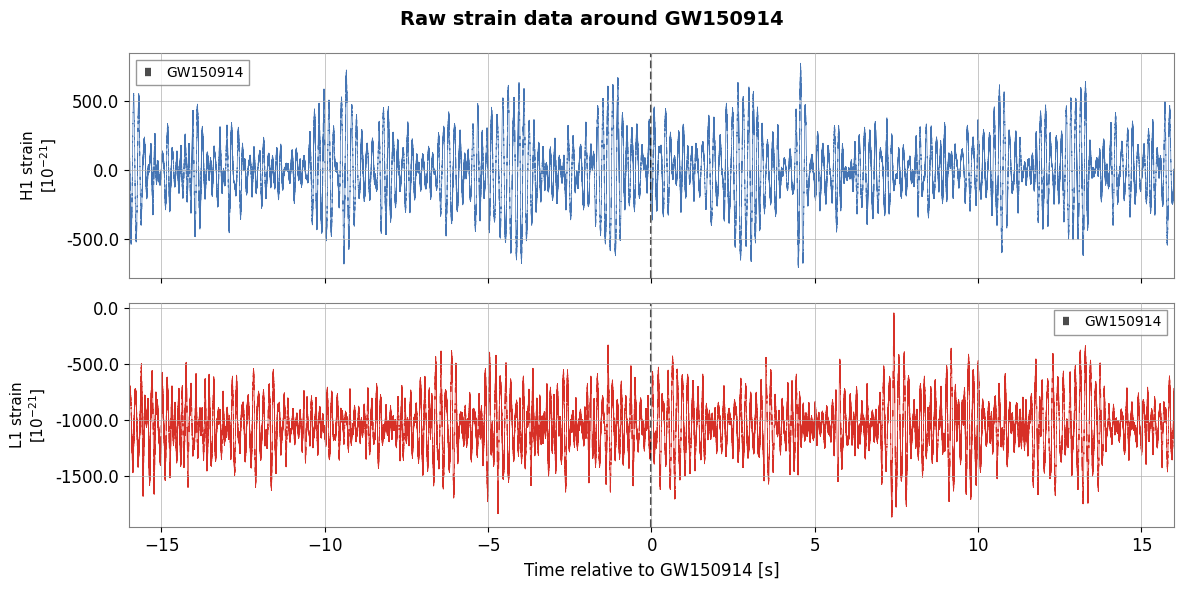

In [27]:
# Cell 22 - Time-domain strain plot
import matplotlib.pyplot as plt
from gwpy.timeseries import TimeSeries
import matplotlib.ticker as ticker
from gwosc import datasets

gps_event = datasets.event_gps("GW150914")

# Use the 32-second TimeSeries fetched in Cell 12
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

for ax, (ifo, color) in zip(axes, [("H1", "#4575b4"), ("L1", "#d73027")]):
    try:
        data = TimeSeries.fetch_open_data(
            ifo, gps_event - 16, gps_event + 16, sample_rate=4096, verbose=False
        )
        t_rel = data.times.value - gps_event
        ax.plot(t_rel, data.value * 1e21, color=color, lw=0.5)
        ax.set_ylabel(f"{ifo} strain\n" + r"[$10^{-21}$]", fontsize=11)
        ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
        ax.axvline(0, color="k", lw=1.5, linestyle="--", alpha=0.7, label="GW150914")
        ax.legend(fontsize=10)
        ax.set_xlim(-16, 16)
    except Exception as e:
        ax.text(0.5, 0.5, f"Could not fetch {ifo}: {e}",
                ha="center", va="center", transform=ax.transAxes)

axes[-1].set_xlabel("Time relative to GW150914 [s]", fontsize=12)
fig.suptitle("Raw strain data around GW150914", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Notice that the GW signal is completely invisible in the raw time series — it is buried under the broadband noise. We need spectral analysis to understand the noise floor, and bandpass filtering to reveal the signal.

### 8.2 Power Spectral Density (PSD)

The **Power Spectral Density (PSD)** $S_n(f)$ quantifies how noise power is distributed across frequencies. It is defined such that the total RMS noise in a bandwidth $[f_1, f_2]$ is:

$$
\sigma^2 = \int_{f_1}^{f_2} S_n(f)\, df
$$

For gravitational-wave strain data, $S_n(f)$ has units of $\text{strain}^2/\text{Hz}$. The PSD is estimated from the data using the **Welch method** — average of many short FFTs:

$$
\hat{S}_n(f) = \frac{1}{M}\sum_{k=1}^{M} |\tilde{h}_k(f)|^2
$$

where $\tilde{h}_k(f)$ is the DFT of the $k$-th windowed segment.

In [28]:
# Cell 23 - Download a longer stretch and compute the PSD
from gwpy.timeseries import TimeSeries
from gwosc import datasets

gps_event = datasets.event_gps("GW150914")

# Download 512 seconds of H1 data (enough for a good PSD estimate)
try:
    h1_long = TimeSeries.fetch_open_data(
        "H1", gps_event - 256, gps_event + 256, sample_rate=4096, verbose=False
    )
    print(f"Downloaded {h1_long.duration} of H1 data.")
except Exception as e:
    print(f"Could not download long stretch: {e}")
    print("Using shorter stretch instead.")
    h1_long = h1_data  # Fall back to 32 s

Downloaded 512.0 s of H1 data.


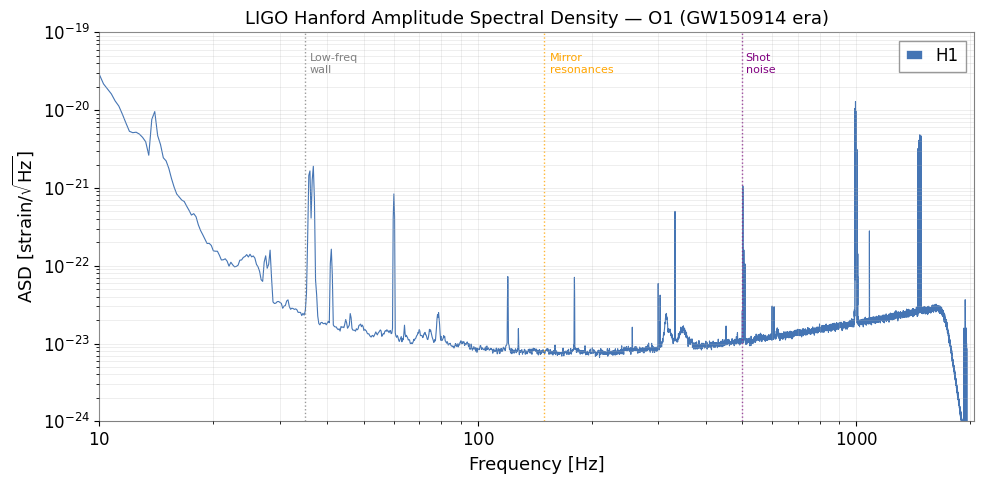

In [29]:
# Cell 24 - Compute and plot the PSD using the Welch method
import matplotlib.pyplot as plt
import numpy as np

# Compute PSD with 4-second FFT segments (gives 0.25 Hz frequency resolution)
psd = h1_long.psd(fftlength=4, overlap=2, window="hann", method="median")

fig, ax = plt.subplots(figsize=(10, 5))
ax.loglog(psd.frequencies.value, psd.value**0.5, color="#4575b4", lw=0.8, label="H1")
ax.set_xlabel("Frequency [Hz]", fontsize=13)
ax.set_ylabel(r"ASD $[\mathrm{strain}/\sqrt{\mathrm{Hz}}]$", fontsize=13)
ax.set_title("LIGO Hanford Amplitude Spectral Density - O1 (GW150914 era)", fontsize=13)
ax.set_xlim(10, 2048)
ax.set_ylim(1e-24, 1e-19)
ax.legend(fontsize=12)
ax.grid(True, which="both", alpha=0.3)

# Annotate key noise features
ax.axvline(35, color="gray", lw=1, linestyle=":", alpha=0.8)
ax.text(36, 3e-20, "Low-freq\nwall", fontsize=8, color="gray")
ax.axvline(150, color="orange", lw=1, linestyle=":", alpha=0.8)
ax.text(155, 3e-20, "Mirror\nresonances", fontsize=8, color="orange")
ax.axvline(500, color="purple", lw=1, linestyle=":", alpha=0.8)
ax.text(510, 3e-20, "Shot\nnoise", fontsize=8, color="purple")

plt.tight_layout()
plt.show()

### 8.3 The Amplitude Spectral Density (ASD)

The **Amplitude Spectral Density (ASD)** is simply $\sqrt{S_n(f)}$ and has units of $\text{strain}/\sqrt{\text{Hz}}$. It is more commonly used in GW literature because its value at a given frequency can be compared directly to the strain amplitude of a signal.

For Advanced LIGO at design sensitivity:
- **Low-frequency wall** (~10 Hz): seismic noise and quantum back-action dominate.
- **Mid-band** (50–500 Hz): thermal noise in mirror coatings and suspensions.
- **High-frequency** (>500 Hz): quantum shot noise scales as $\sqrt{f}$.
- **Spectral lines**: 60 Hz power mains and harmonics, violin modes of suspension fibres (~500 Hz), calibration lines.

The **best sensitivity** (lowest ASD) is in the range **100–300 Hz**, which is also where binary black hole mergers radiate most of their energy.

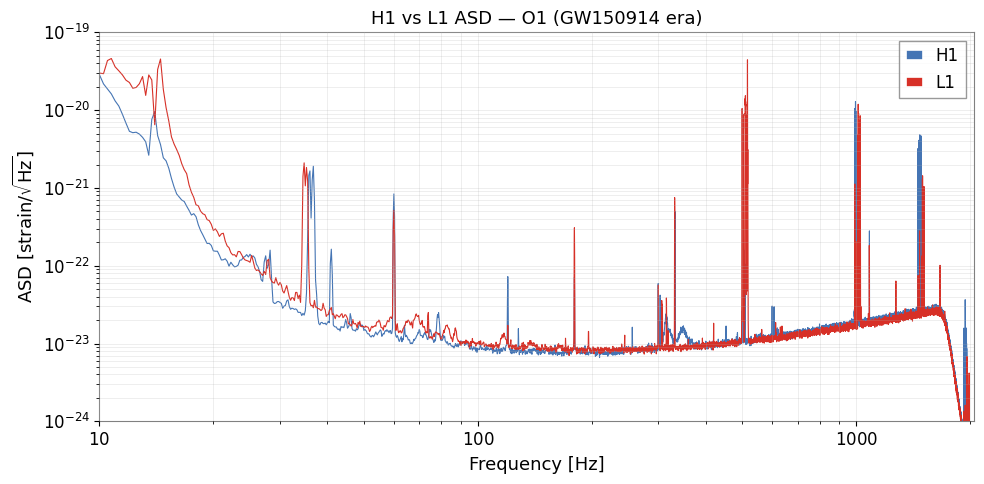

In [30]:
# Cell 25 - Compare H1 and L1 ASDs
import matplotlib.pyplot as plt
from gwpy.timeseries import TimeSeries
from gwosc import datasets

gps_event = datasets.event_gps("GW150914")
fig, ax = plt.subplots(figsize=(10, 5))

colors = {"H1": "#4575b4", "L1": "#d73027"}
for ifo, color in colors.items():
    try:
        data = TimeSeries.fetch_open_data(
            ifo, gps_event - 256, gps_event + 256, sample_rate=4096, verbose=False
        )
        psd = data.psd(fftlength=4, overlap=2, window="hann", method="median")
        asd = psd.value**0.5
        ax.loglog(psd.frequencies.value, asd, lw=0.8, color=color, label=ifo)
    except Exception as e:
        print(f"  {ifo}: {e}")

ax.set_xlabel("Frequency [Hz]", fontsize=13)
ax.set_ylabel(r"ASD $[\mathrm{strain}/\sqrt{\mathrm{Hz}}]$", fontsize=13)
ax.set_title("H1 vs L1 ASD - O1 (GW150914 era)", fontsize=13)
ax.set_xlim(10, 2048)
ax.set_ylim(1e-24, 1e-19)
ax.legend(fontsize=12)
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

### 8.4 Q-Transform (Time–Frequency Representation)

The **Q-transform** is a time–frequency analysis method particularly well-suited to transient GW signals. It is a weighted short-time Fourier transform where the time resolution adapts with frequency, maintaining a constant quality factor $Q$:

$$
X(\tau, f_0) = \int_{-\infty}^{\infty} x(t)\, g(t-\tau, f_0)\, e^{-2\pi i f_0 t}\, dt
$$

where $g(t, f_0)$ is a Gaussian window with $\Delta t \propto Q/f_0$ (wider at low $f$, narrower at high $f$). The Q-transform shows the **normalised energy** in each time-frequency pixel, making GW chirps and glitches immediately visible as bright tracks.

> **GW chirps** appear as upward sweeps in frequency (frequency increases as the binary inspiral accelerates).
> **Glitches** (detector artefacts) appear as short-duration, broad-frequency blobs.

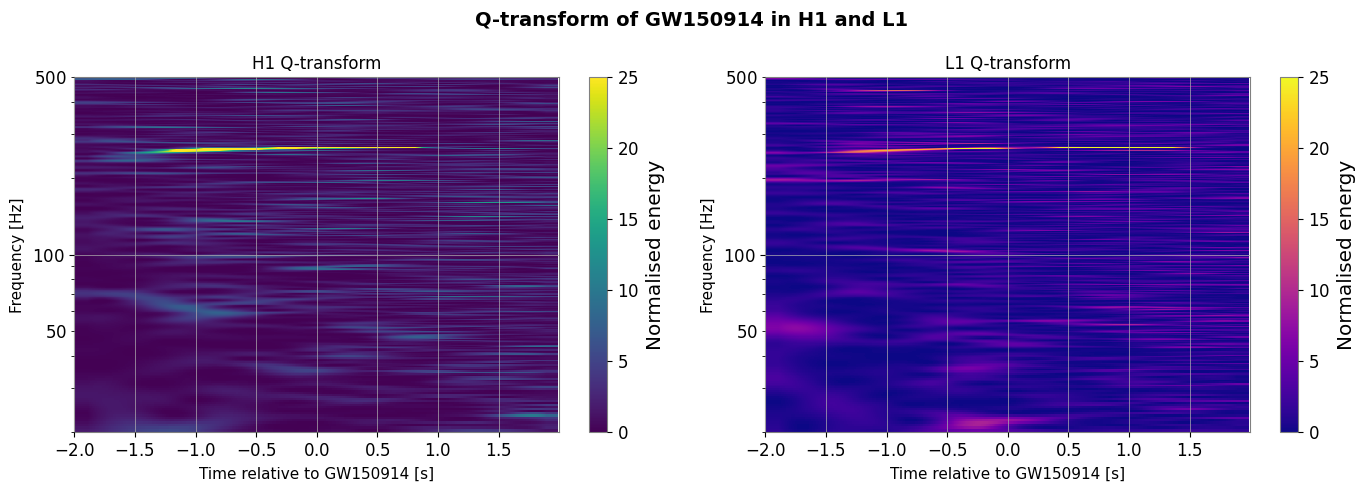

In [31]:
# Cell 26 - Compute and plot the Q-transform for GW150914
import matplotlib.pyplot as plt
from gwpy.timeseries import TimeSeries
from gwosc import datasets

gps_event = datasets.event_gps("GW150914")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, ifo, color in zip(axes, ["H1", "L1"], ["viridis", "plasma"]):
    try:
        data = TimeSeries.fetch_open_data(
            ifo, gps_event - 16, gps_event + 16, sample_rate=4096, verbose=False
        )
        # Compute Q-transform
        qtransform = data.q_transform(
            frange=(20, 500),    # frequency range [Hz]
            qrange=(4, 64),      # range of Q values to try
            outseg=(gps_event - 2, gps_event + 2),  # output time window
            logf=True,           # logarithmic frequency axis
            norm="median",       # normalisation mode
        )
        im = ax.imshow(
            qtransform.T,
            aspect="auto",
            origin="lower",
            extent=[
                qtransform.xindex.value[0]  - gps_event,
                qtransform.xindex.value[-1] - gps_event,
                qtransform.yindex.value[0],
                qtransform.yindex.value[-1],
            ],
            cmap=color,
            vmin=0, vmax=25,
        )
        ax.set_xlabel("Time relative to GW150914 [s]", fontsize=11)
        ax.set_ylabel("Frequency [Hz]", fontsize=11)
        ax.set_title(f"{ifo} Q-transform", fontsize=12)
        ax.set_yscale("log")
        plt.colorbar(im, ax=ax, label="Normalised energy")
    except Exception as e:
        ax.text(0.5, 0.5, f"{ifo}: {e}", ha="center", va="center",
                transform=ax.transAxes, fontsize=9)

fig.suptitle("Q-transform of GW150914 in H1 and L1", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

The Q-transform clearly shows the **gravitational-wave chirp** from GW150914: a bright track that sweeps upward from ~30 Hz to ~200 Hz over about 0.4 seconds, arriving ~7 ms earlier in Hanford than in Livingston (consistent with the sky location of the source).

Key interpretations:
- **Bright track (high normalised energy):** GW signal.
- **Horizontal lines:** persistent noise lines (e.g., 60 Hz harmonics).
- **Isolated blobs:** transient noise artefacts (glitches).
- **Background level ~1:** consistent with Gaussian noise.

---
## 9. Data Quality and Segments

### 9.1 Data Quality Flags

Not all recorded data is suitable for gravitational-wave searches. **Data quality flags** (DQ flags) record times when the detector was in a particular state. Key flag categories:

| Flag Category | Meaning |
|---------------|---------|
| **Science mode** | Detector locked, in standard observation configuration |
| **CBC CAT1** | Category 1: hardware problems, data definitely unusable |
| **CBC CAT2** | Category 2: statistically correlated with detector artefacts |
| **CBC CAT3** | Category 3: possible correlation with noise, use with caution |
| **Injection** | Hardware or software signal injected into the data stream |

GW searches typically require data to be in **Science mode AND pass CAT1 vetoes** at minimum.

### 9.2 Querying Segments with `gwosc`

The `gwosc.timeline` module provides a programmatic interface to GWOSC's segment data.

In [32]:
# Cell 27 - Query data-quality flags with gwosc.timeline
from gwosc import timeline

# Define a time range around GW150914
t_start = 1126257415  # GPS start of the 4096-s file containing GW150914
t_end   = t_start + 4096

# Get the science-mode segments for H1
# Flag name: H1_DATA
segments = timeline.get_segments("H1_DATA", t_start, t_end)
print(f"H1_DATA segments between GPS {t_start} and {t_end}:")
total_science = 0
for seg in segments:
    duration = seg[1] - seg[0]
    total_science += duration
    print(f"  [{seg[0]}, {seg[1]}]  -> {duration} s")
print(f"Total science time: {total_science} / {t_end - t_start} s ({100*total_science/(t_end-t_start):.1f}%)")

H1_DATA segments between GPS 1126257415 and 1126261511:
  [1126257415, 1126261511]  → 4096 s
Total science time: 4096 / 4096 s (100.0%)


In [33]:
# Cell 28 - List available flags for a detector
from gwosc import timeline

# Available flags for H1 around GW150914
try:
    flags = timeline.get_flag_names("H1", 1126257415, 1126261511)
    print("Available DQ flags for H1 in this interval:")
    for flag in sorted(flags):
        print(f"  {flag}")
except AttributeError:
    # Older gwosc versions don't have get_flag_names
    print("Commonly used GWOSC DQ flags:")
    common_flags = [
        "H1_DATA",
        "H1_CBC_CAT1",
        "H1_CBC_CAT2",
        "H1_CBC_CAT3",
        "H1_BURST_CAT1",
        "H1_BURST_CAT2",
        "H1_INJECTION",
        "L1_DATA",
        "L1_CBC_CAT1",
        "L1_CBC_CAT2",
    ]
    for f in common_flags:
        print(f"  {f}")

Commonly used GWOSC DQ flags:
  H1_DATA
  H1_CBC_CAT1
  H1_CBC_CAT2
  H1_CBC_CAT3
  H1_BURST_CAT1
  H1_BURST_CAT2
  H1_INJECTION
  L1_DATA
  L1_CBC_CAT1
  L1_CBC_CAT2


### 9.3 Science Mode and Analysis Segments

**Science mode** (also called `H1_DATA` or `L1_DATA` in GWOSC terminology) means the detector is:
- Locked and operating normally.
- Producing calibrated strain.
- Below the threshold for known noise problems.

For a confident GW detection, all participating detectors must be in Science mode simultaneously. The **duty cycle** (fraction of time in Science mode) is typically 60–80% for a single detector and ~50% for coincident two-detector operation.

The cell below visualises the Science mode duty cycle for O1.

In [34]:
# Cell 29 - O1 duty cycle estimate for H1 and L1
from gwosc import timeline, datasets

# O1 run span
o1_span = datasets.run_segment("O1")
t_start_o1, t_end_o1 = o1_span
o1_duration = t_end_o1 - t_start_o1

print(f"O1 GPS span: {t_start_o1} - {t_end_o1}")
print(f"O1 duration: {o1_duration} s = {o1_duration/86400:.1f} days")
print()

for ifo in ["H1", "L1"]:
    flag = f"{ifo}_DATA"
    try:
        segs = timeline.get_segments(flag, t_start_o1, t_end_o1)
        science_time = sum(s[1] - s[0] for s in segs)
        duty = 100.0 * science_time / o1_duration
        print(f"{ifo} Science mode: {science_time/3600:.1f} h / {o1_duration/3600:.1f} h ({duty:.1f}%)")
    except Exception as e:
        print(f"{ifo}: {e}")

O1 GPS span: 1126051217 – 1137254417
O1 duration: 11203200 s = 129.7 days

H1 Science mode: 1840.8 h / 3112.0 h (59.2%)
L1 Science mode: 1579.4 h / 3112.0 h (50.8%)


---
## 10. Working with PyCBC

### 10.1 PyCBC TimeSeries

**PyCBC** is a comprehensive GW analysis toolkit developed primarily by the LIGO Scientific Collaboration. Its `pycbc.types.TimeSeries` class is similar to `gwpy.TimeSeries` but is designed for signal-processing pipelines.

Key differences from `gwpy`:
- PyCBC `TimeSeries` stores `epoch` (GPS start) and `delta_t` (sample spacing).
- PyCBC is more tightly integrated with matched-filter and waveform libraries.
- PyCBC can use GPU acceleration (via CUDA/OpenCL).

### 10.2 Fetching Open Data with PyCBC

In [35]:
# Cell 30 - Fetch strain data with PyCBC
try:
    from pycbc.catalog import Merger
    from pycbc import frame

    # The Merger class wraps GWOSC access for a named event
    merger = Merger("GW150914")
    h1_pycbc = merger.strain("H1")

    print("PyCBC TimeSeries for H1 around GW150914:")
    print(f"  dtype       : {h1_pycbc.dtype}")
    print(f"  sample_rate : {1.0/h1_pycbc.delta_t:.0f} Hz")
    print(f"  delta_t     : {h1_pycbc.delta_t} s")
    print(f"  GPS start   : {float(h1_pycbc.start_time):.1f}")
    print(f"  GPS end     : {float(h1_pycbc.end_time):.1f}")
    print(f"  Duration    : {float(h1_pycbc.end_time) - float(h1_pycbc.start_time):.1f} s")
    print(f"  Length      : {len(h1_pycbc)} samples")
except ImportError:
    print("PyCBC is not installed. Install it with: pip install pycbc")
except Exception as e:
    print(f"PyCBC error: {e}")

PyCBC TimeSeries for H1 around GW150914:
  dtype       : float64
  sample_rate : 4096 Hz
  delta_t     : 0.000244140625 s
  GPS start   : 1126259447.0
  GPS end     : 1126259479.0
  Duration    : 32.0 s
  Length      : 131072 samples


In [36]:
# Cell 31 - Alternative: load strain from HDF5 file into a PyCBC TimeSeries
try:
    from pycbc.types import TimeSeries as PyCBCTimeSeries
    import numpy as np
    import h5py

    with h5py.File(filename, "r") as f:
        strain_array = f["strain"]["Strain"][:].astype(np.float64)
        gps_start_val = float(f["strain"]["Strain"].attrs["Xstart"])
        dt_val = float(f["strain"]["Strain"].attrs["Xspacing"])

    h1_pycbc_manual = PyCBCTimeSeries(
        strain_array,
        delta_t=dt_val,
        epoch=gps_start_val,
    )
    print("PyCBC TimeSeries from manual HDF5 read:")
    print(f"  Sample rate : {1.0/h1_pycbc_manual.delta_t:.0f} Hz")
    print(f"  GPS start   : {float(h1_pycbc_manual.start_time):.1f}")
    print(f"  Duration    : {float(h1_pycbc_manual.duration):.1f} s")
except ImportError:
    print("PyCBC is not installed.")
except Exception as e:
    print(f"Error: {e}")

PyCBC TimeSeries from manual HDF5 read:
  Sample rate : 4096 Hz
  GPS start   : 1126256640.0
  Duration    : 4096.0 s


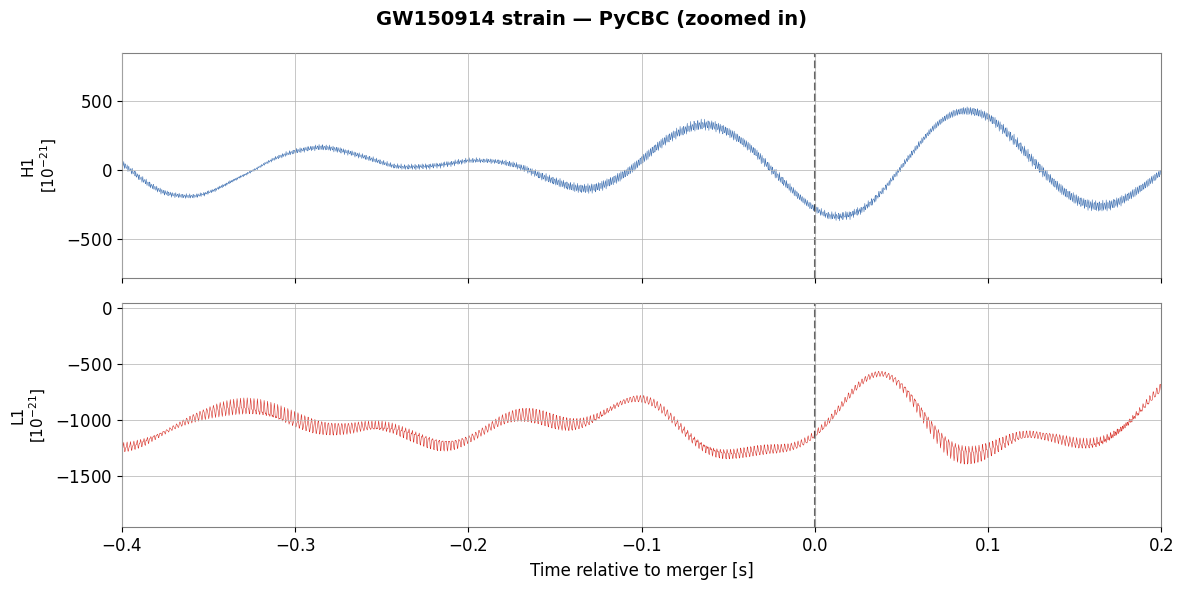

In [37]:
# Cell 32 - Quick PyCBC time-domain plot
try:
    import matplotlib.pyplot as plt
    from pycbc.catalog import Merger

    merger = Merger("GW150914")
    gps_evt = merger.time

    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    colors = {"H1": "#4575b4", "L1": "#d73027"}

    for ax, ifo in zip(axes, ["H1", "L1"]):
        data = merger.strain(ifo)
        times = data.sample_times.numpy() - gps_evt
        ax.plot(times, data.numpy() * 1e21, lw=0.4, color=colors[ifo])
        ax.set_ylabel(f"{ifo}\n" + r"[$10^{-21}$]", fontsize=11)
        ax.axvline(0, color="k", lw=1.5, ls="--", alpha=0.6)
        ax.set_xlim(-0.4, 0.2)

    axes[-1].set_xlabel("Time relative to merger [s]", fontsize=12)
    fig.suptitle("GW150914 strain - PyCBC (zoomed in)", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()
except ImportError:
    print("PyCBC not installed - skipping plot.")
except Exception as e:
    print(f"Plot error: {e}")

---
## 11. Student Exercises

The following exercises are designed to reinforce the concepts covered in this lesson. They range from conceptual questions to hands-on coding tasks.

---

### Exercise 1 — GPS Time Arithmetic *

**Conceptual.** The signal GW170817 (the first binary neutron star merger) arrived at Earth at GPS time **1187008882.4 s**.

1. Convert this GPS time to a UTC date and time using `astropy`.
2. What day of the week was it?
3. What is the elapsed time in days between GW150914 (GPS 1126259462.4) and GW170817?
4. What is the difference in GPS time between these two events?

---

### Exercise 2 — Catalogue Exploration **

**Coding.** Using the `gwosc` package:

1. List all events in **GWTC-3** and count how many involve three or more detectors.
2. Find the event with the **earliest GPS time** in the entire catalogue.
3. Find the event with the **latest GPS time** in the entire catalogue.
4. Plot a **timeline bar chart** showing all events colour-coded by run (O1, O2, O3a, O3b). (*Hint:* use `plt.barh` or `plt.eventplot`.)

---

### Exercise 3 — Inspecting File Contents **

**Coding.** Download the 4096-second H1 bulk file containing GW150914 (sample rate 4096 Hz).

1. Print the complete HDF5 tree (groups, datasets, attributes).
2. Extract the sample rate, GPS start, GPS end, and total number of samples.
3. Verify that `num_samples = sample_rate × duration`.
4. Compute the RMS strain over the entire 4096-second file.
5. Compare the RMS to the RMS of a 32-second segment centred on the event — are they similar? Why?

---

### Exercise 4 — The Detector Noise Budget ***

**Analysis.** For the LIGO Hanford detector during O1:

1. Compute and plot the ASD in the range 10–2000 Hz.
2. Identify the **60 Hz power line** and its first three harmonics (120, 180, 240 Hz) in the ASD. Are they visible?
3. Estimate the **minimum ASD** (best sensitivity) and at what frequency it occurs.
4. The GW150914 signal had peak strain $h_{\rm peak} \approx 10^{-21}$ at $\sim 150$ Hz. Read off the ASD at 150 Hz and compute the approximate **signal-to-noise ratio** per $\sqrt{\text{Hz}}$: SNR $\approx h_{\rm peak} / \text{ASD}(150\,\text{Hz})$.

---

### Exercise 5 — Q-Transform Exploration ***

**Coding.** Compute Q-transforms for **three different events** from the GWTC-1 catalogue:

1. GW150914 (binary black hole)
2. GW170817 (binary neutron star) — note: this event has a much longer chirp
3. GW151226 (lower-mass binary black hole)

For each event:
- Use a frequency range of 20–500 Hz.
- Zoom in to $\pm 2$ s around the merger.
- Describe in words what you observe: How long is the chirp visible? At what frequency does it start and end?

*Extra:* Why does GW170817 have a much longer track in the Q-transform than GW150914?

---

### Exercise 6 — Data Quality Investigation **

**Analysis.** For the O2 observing run:

1. Use `gwosc.timeline` to get the Science-mode (`H1_DATA`) segments for the first week of O2.
2. Compute the duty cycle (percentage of time in Science mode).
3. Identify the **longest continuous Science-mode segment**.
4. Plot a simple **segment plot** (a horizontal bar for each Science-mode segment) using `matplotlib`.

---

### Exercise 7 — Cross-Detector Comparison ***

**Coding.** For the binary neutron star event **GW170814** (the first three-detector observation, involving H1, L1, and V1):

1. Retrieve the GPS time of GW170814.
2. Download 32-second strain segments from all three detectors.
3. Plot the Q-transform for each detector side-by-side.
4. The signal arrives at different times in each detector (because they are at different geographic locations). Qualitatively, does the Q-transform show this?
5. Look up the sky localisation area for GW170814 in the GWOSC event page. How many square degrees is the 90% credible region? Compare to GW150914 (two detectors only).

---

### Exercise 8 — File Format Comparison **

**Coding.** If your GWOSC download returned both `.hdf5` and `.gwf` versions of the same data:

1. Read both files (HDF5 with `h5py`, GWF with `gwpy`).
2. Check that the strain values are **bit-for-bit identical** or at least agree to machine precision.
3. Compare the file sizes on disk.
4. Which format would you prefer for interactive work? For archival storage? Justify your answer.

---

### Exercise 9 — Your Own Event ****

**Open-ended.** Choose any event from GWTC-2 or GWTC-3 that you find interesting (e.g., GW190521 — the most massive binary black hole merger observed). Then:

1. Download 32 s of strain from all available detectors.
2. Plot the raw time series, ASD, and Q-transform for each detector.
3. Briefly describe what you see in the Q-transform.
4. Write a short paragraph (3–5 sentences) about the physical significance of this event — what makes it interesting or unusual?

---

### Exercise 10 — `gwosc` vs `gwpy` vs `pycbc` *

**Conceptual.** Based on what you have learned in this lesson:

1. What is the primary purpose of `gwosc`? What kind of tasks is it NOT well-suited for?
2. What is the main advantage of `gwpy.TimeSeries` over raw `h5py` loading?
3. In what context would you choose `pycbc` over `gwpy` for loading and working with strain data?
4. Can you use `gwosc` to find data URLs and then load the data with `pycbc`? Describe how.

---
## 12. References

### Primary Software Documentation

1. **GWOSC Python package** — `gwosc`  
   Documentation: https://gwosc.readthedocs.io  
   Source: https://github.com/gwpy/gwosc  
   Installation: `pip install gwosc`

2. **GWpy** — `gwpy`  
   Documentation: https://gwpy.github.io/docs/stable/  
   Source: https://github.com/gwpy/gwpy  
   Paper: Macas et al. (2022), *SoftwareX* 19, 101216. https://doi.org/10.1016/j.softx.2022.101216

3. **PyCBC** — `pycbc`  
   Documentation: https://pycbc.org/pycbc/latest/html/  
   Source: https://github.com/gwastro/pycbc  
   Paper: Biwer et al. (2019), *PASP* 131, 024503. https://doi.org/10.1088/1538-3873/aaef0b

### GWOSC Resources

4. **Gravitational-Wave Open Science Center**  
   Website: https://gwosc.org  
   Tutorials: https://gwosc.org/tutorials/

5. **GWOSC Data Release Paper** (O3)  
   Abbott et al. (2023), *ApJS* 267, 29. https://doi.org/10.3847/1538-4365/acdc9f

6. **GWOSC Data Release Paper** (O1 and O2)  
   Vallisneri et al. (2015), *Proceedings of the 10th LISA Symposium*. https://arxiv.org/abs/1410.4839

### Event Catalogues

7. **GWTC-1**: Abbott et al. (2019), *Physical Review X* 9, 031040.  
   https://doi.org/10.1103/PhysRevX.9.031040

8. **GWTC-2**: Abbott et al. (2021), *Physical Review X* 11, 021053.  
   https://doi.org/10.1103/PhysRevX.11.021053

9. **GWTC-3**: Abbott et al. (2023), *Physical Review X* 13, 041039.  
   https://doi.org/10.1103/PhysRevX.13.041039

### File Format References

10. **HDF5 Format**  
    The HDF Group, https://www.hdfgroup.org/solutions/hdf5/  
    Python interface (`h5py`): https://www.h5py.org

11. **GWF (Frame) Format**  
    Livas et al. (1997), *LIGO Document T970131.*  
    `framel` library: https://git.ligo.org/lscsoft/framel

### GPS Time

12. **GPS Time** — International Bureau of Weights and Measures (BIPM)  
    https://www.bipm.org/en/time-ftp/leap-seconds

13. **Astropy Time package** — `astropy.time`  
    Documentation: https://docs.astropy.org/en/stable/time/  
    Astropy Collaboration (2022), *ApJ* 935, 167. https://doi.org/10.3847/1538-4357/ac7c74

### Recommended Tutorials and Notebooks

14. **GWOSC Official Tutorials** (Jupyter notebooks)  
    https://gwosc.org/tutorials/  
    Topics: strain data, signal processing, matched filtering, parameter estimation.

15. **GW Open Data Workshop Materials**  
    https://gwosc.org/odw/  
    Annual workshops with lecture videos and notebooks.

16. **PyCBC Tutorials**  
    https://pycbc.org/pycbc/latest/html/tutorials.html

17. **Gravitational Wave Data Analysis** (lecture notes)  
    Jaranowski & Królak (2009), Cambridge University Press.  
    ISBN: 978-0-521-86465-8

---

**Next lesson:** [Lesson 3 — Signal Processing Fundamentals: Filtering, Whitening, and FFTs](../Lesson_03_Signal_Processing_Fundamentals.ipynb)